**Desafio 1: Convolução de sinais simulados**

A função conv é usada para convoluir duas funções discretas x[n] e h[n]. Ela assume que o incremento temporal é o mesmo em ambos sinais. O resultado da convolução tem tamanho igual à soma dos tamanhos de cada sinal menos um ponto (L1 + L2 − 1).

1. Um sistema linear invariante no tempo é completamente descrito por sua resposta ao impulso. Por exemplo, considere o sistema com resposta ao impulso h = [1 zeros(1,20) 0.5 zeros(1,10)];. Crie um script usando o editor e plote essa resposta ao impulso.



In [54]:
import numpy as np
import matplotlib.pyplot as plt

# Building the h signal

h = np.concatenate([
    np.array([1.0]),
    np.zeros(20),
    np.array([0.5]),
    np.zeros(10)
])
print(h)

[1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.5 0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]


2. Considere a seguinte entrada no sistema x = [0 1:10 ones(1,5)*5 zeros(1,10)];. Plote esta entrada.

In [55]:
# Building x signal
x = np.concatenate([
    np.array([0.0]),
    np.arange(1, 11, dtype=float),
    np.ones(5, dtype=float) * 5.0,
    np.zeros(10, dtype=float)
])
print(x)

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.  5.  5.  5.  5.  5.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.]



3. Convolua x e h, i.e., y = conv(x,h); Use o comando subplot para mostrar a resposta ao impulso, a entrada e a saída.

26
32
57


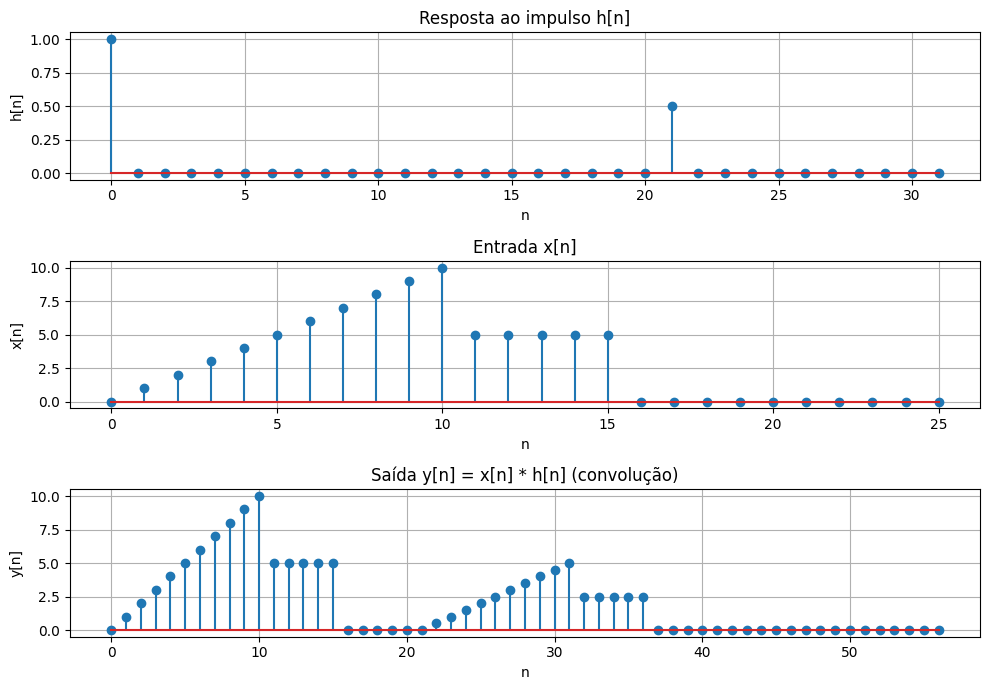

len(h) = 32
len(x) = 26
len(y) = 57  (deve ser len(x)+len(h)-1 = 57 )


In [56]:
y = np.convolve(x, h)
print(x.size)
print(h.size)
print(y.size)

# as expected length is len(x) + len(h) -1 > 26 + 32 - 1=57

#image configuration
nh = np.arange(len(h))
nx = np.arange(len(x))
ny = np.arange(len(y))

#plot image
plt.figure(figsize=(10, 7))
plt.subplot(3, 1, 1)
plt.stem(nh, h)
plt.title("Resposta ao impulso h[n]")
plt.xlabel("n")
plt.ylabel("h[n]")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.stem(nx, x)
plt.title("Entrada x[n]")
plt.xlabel("n")
plt.ylabel("x[n]")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.stem(ny, y)
plt.title("Saída y[n] = x[n] * h[n] (convolução)")
plt.xlabel("n")
plt.ylabel("y[n]")
plt.grid(True)

plt.tight_layout()
plt.show()

print("len(h) =", len(h))
print("len(x) =", len(x))
print("len(y) =", len(y), " (deve ser len(x)+len(h)-1 =", len(x)+len(h)-1, ")")


**Desafio 2: Resposta ao impulso quadrado**

Primeiro iremos carregar o arquivo e o plottar.

Fs = 22050.0
y.shape = (28000,)


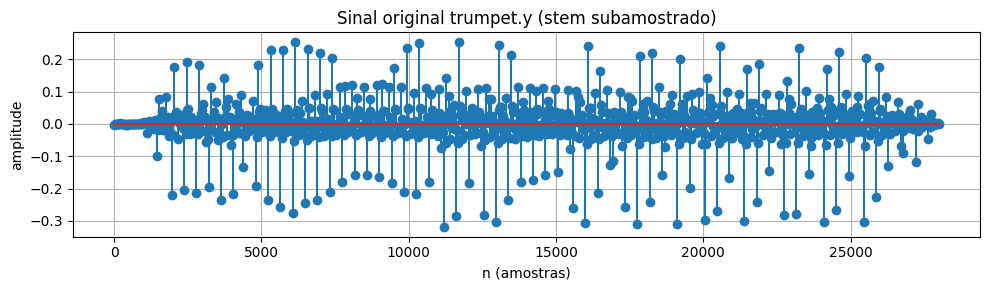

In [57]:
from scipy.io import loadmat
from IPython.display import Audio, display

mat = loadmat("/content/trumpet.mat")
Fs = float(mat["Fs"].squeeze())
y  = mat["y"].squeeze().astype(float)

print("Fs =", Fs)
print("y.shape =", y.shape)

step = 30  # reduce sampling so the image is not so poluted
n_y = np.arange(0, len(y), step)

plt.figure(figsize=(10, 3))
plt.stem(n_y, y[::step])
plt.title("Sinal original trumpet.y (stem subamostrado)")
plt.xlabel("n (amostras)")
plt.ylabel("amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()


Criaremos então o sinal h2 =  [ones(1,50)/50 zeros(1,20)]

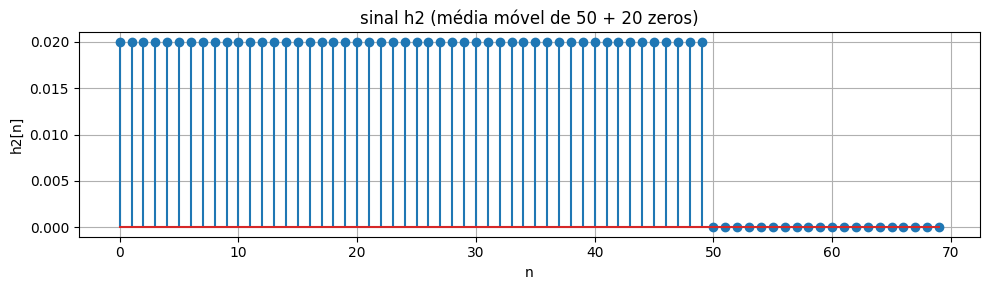

In [58]:
h2 = np.concatenate([np.ones(50)/50.0, np.zeros(20)])
plt.figure(figsize=(10, 3))
plt.stem(np.arange(len(h2)), h2)
plt.title("sinal h2 (média móvel de 50 + 20 zeros)")
plt.xlabel("n")
plt.ylabel("h2[n]")
plt.grid(True)
plt.tight_layout()
plt.show()

Convoluiremos então y e h2

len(y)  = 28000
len(h2) = 70
len(y2) = 28069  (deve ser len(y)+len(h2)-1)


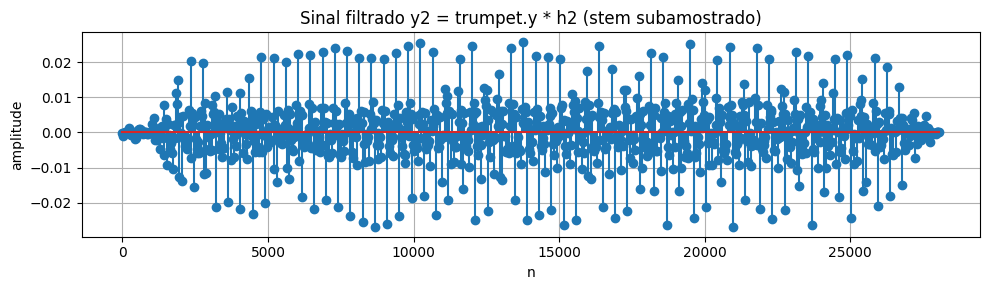

In [59]:
y2 = np.convolve(y, h2)

print("len(y)  =", len(y))
print("len(h2) =", len(h2))
print("len(y2) =", len(y2), " (deve ser len(y)+len(h2)-1)")

# Plot y2 (subamostrado)
n_y2 = np.arange(0, len(y2), step)
plt.figure(figsize=(10, 3))
plt.stem(n_y2, y2[::step])
plt.title("Sinal filtrado y2 = trumpet.y * h2 (stem subamostrado)")
plt.xlabel("n")
plt.ylabel("amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()


Iremos ouvir agora o audio original e o filtrado.

In [60]:
y2_same = y2[:len(y)]

print("Áudio original:")
display(Audio(y, rate=int(Fs)))

print("Áudio filtrado (passa-baixa):")
display(Audio(y2_same, rate=int(Fs)))


Áudio original:


Áudio filtrado (passa-baixa):


Como o sinal convoluído soa?

Intuitivamente o sinal h2 tem a inteção de suprimir frequencias mais altas e é exatamente isso que vemos, um som menos agudo. O fator de 1/50 é o que controla quanto de suavização será feito. O numero de 1s aumenta ou diminui a janela, qual a faixa de corte do filtro.

**Desafio 3: Realce de imagens lunares**

Primeiramente carregaremos a imagem fornecida.


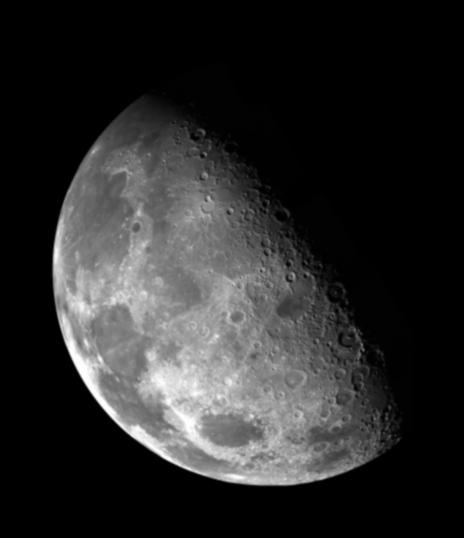

In [61]:
import cv2
from scipy.signal import convolve2d
from google.colab.patches import cv2_imshow

I = cv2.imread("/content/lua.jpg", cv2.IMREAD_GRAYSCALE)
cv2_imshow(I)


Faremos então realce nos detalhes da imagem. Para isto, use o kernel (descrito por um filtro de Laplace)

In [62]:
F = np.array([[-1, -1, -1],
              [-1,  8, -1],
              [-1, -1, -1]], dtype=float)

Faremos a convolução 2D entre a imagem e o kernel

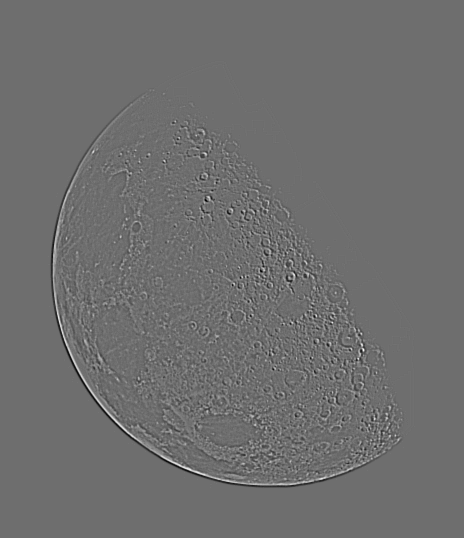

In [63]:
I_float = I.astype(float)
L = convolve2d(I_float, F, mode="same", boundary="symm")
L_vis = L - L.min()
L_vis = (255 * L_vis / L_vis.max()).astype(np.uint8)

cv2_imshow(L_vis)


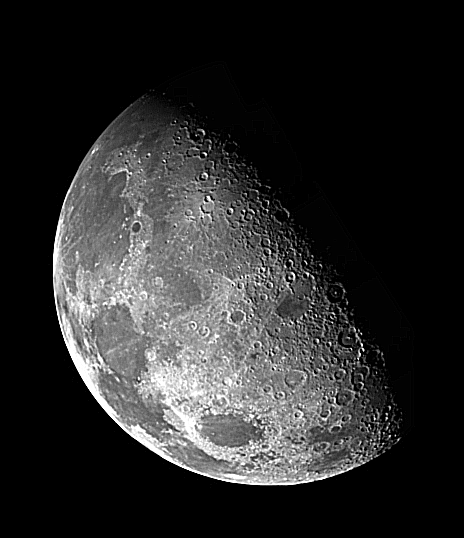

In [64]:
# =========================
# 4) Realce: I + Laplaciano
# =========================
I_realce = I_float + L
I_realce = np.clip(I_realce, 0, 255).astype(np.uint8)

cv2_imshow(I_realce)


A partir da imagem original, aplicamos o Kernel e é possível ver que as bordas final visiveis e regiões que não tem muita transição quase não aparece, fator mais evidenciado pela normalização com o L_vis; Ao somarmos as 2 imagens obtemos o realce. Comparando a ultima imagem com a original vemos um grange destaque para as crateras e para o contorno da lua.


**Desafio 4: Que filtro é esse?**
Carregaremos a imagem dada primeiramente.

In [65]:
I = cv2.imread("/content/texto.jpg", cv2.IMREAD_GRAYSCALE)

Criaremos o Kernel dado

In [66]:
F = (1/9) * np.array([[1, 1, 1],
                      [1, 9, 1],
                      [1, 1, 1]], dtype=float)

Faremos então a convolução 2d e plotaremos o antes e o depois da operação para compararmos.

Original:


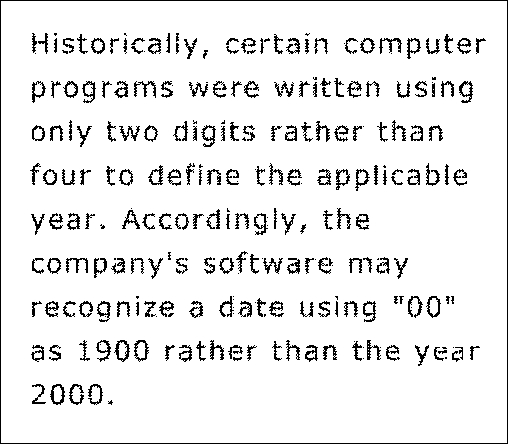

In [67]:
I_f = I.astype(float)
Y = convolve2d(I_f, F, mode="same", boundary="symm")


Y8 = np.clip(Y, 0, 255).astype(np.uint8)

print("Original:")
cv2_imshow(I)



Filtrada (kernel F):


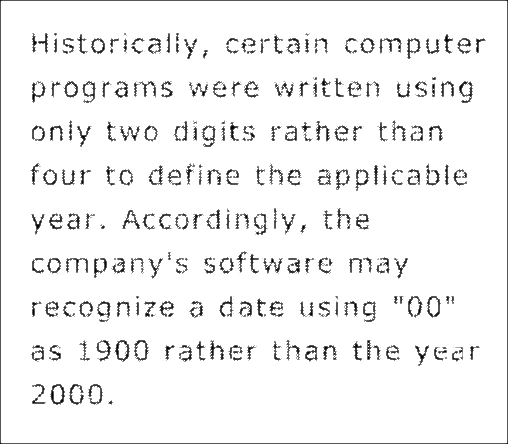

In [68]:
print("Filtrada (kernel F):")
cv2_imshow(Y8)



Diferença |Y - I| (onde mais alterou):


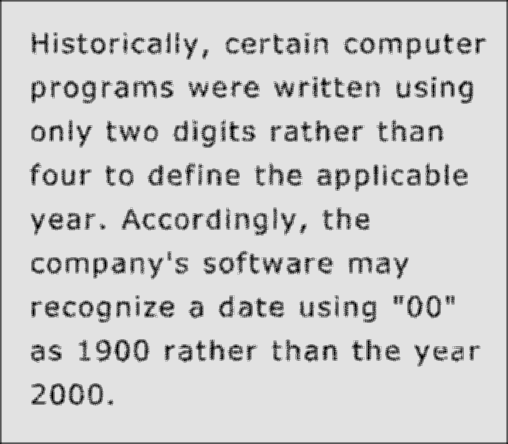

In [69]:
D = np.clip(np.abs(Y - I_f), 0, 255).astype(np.uint8)
print("Diferença |Y - I| (onde mais alterou):")
cv2_imshow(D)

Após a aplicação do filtro, observa-se que a imagem torna-se ligeiramente mais clara, devido ao ganho DC introduzido pelo kernel. As bordas das letras ficam suavizadas, com redução do serrilhamento, e pequenas irregularidades e ruídos do fundo são atenuados. Como efeito colateral, ocorre uma perda de nitidez nos contornos mais finos, comportamento típico de filtros passa-baixa.

O kernel utilizado pode ser classificado como um filtro passa-baixa espacial, do tipo suavização por média ponderada, com ganho DC e peso central dominante. Ele não atua como um filtro de realce de bordas, mas sim como um filtro que atenua componentes de alta frequência espacial, preservando a estrutura geral da imagem.

Em imagens contendo texto, filtros passa-baixa tendem a reduzir ruídos e irregularidades do fundo e a suavizar os contornos das letras, porém à custa da diminuição da nitidez de detalhes finos. Isso explica por que o texto filtrado apresenta aparência mais suave e menos áspera, embora ligeiramente borrada. Esse tipo de filtro é comumente utilizado como etapa de pré-processamento, por exemplo, antes de limiarização ou reconhecimento óptico de caracteres (OCR), com o objetivo de reduzir ruído.